
## Imports 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Régression — Prédiction de `Prix_Revente`


### Chargement des données

In [2]:
df_clean = pd.read_csv("../data/df_clean.csv")

### Features / Target

In [3]:
target = "Prix_Revente"
features = [c for c in df_clean.columns if c not in [target, "Rapport_Collecte"]]

X = df_clean[features]
y = df_clean[target]

print("Features:", features)
print("Shape X:", X.shape)

Features: ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Categorie', 'Source']
Shape X: (9724, 7)


### SPLIT 70 / 15 / 15 

In [4]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42
)

print("\nSplit:")
print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)


Split:
Train: (6806, 7)
Val  : (1459, 7)
Test : (1459, 7)


### Scaling

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


### Fonction d’évaluation

In [6]:
def eval_reg(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)

    mse = mean_squared_error(yte, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(yte, y_pred)
    r2 = r2_score(yte, y_pred)

    print(f"{name:25s} | RMSE={rmse:.4f} | MAE={mae:.4f} | MSE={mse:.4f} | R2={r2:.4f}")

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse,
        "R2": r2,
        "y_pred": y_pred
    }

### MODELES COMPLETS

In [7]:
models = {
    "Régression linéaire": LinearRegression(),

    "Régression Ridge": Ridge(alpha=1),

    "Régression Lasso": Lasso(alpha=0.1, max_iter=5000),

    "Régression polynomiale": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("lr", LinearRegression())
    ]),

    "Bayesian Ridge": BayesianRidge(),

    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),

    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),

    "KNN": KNeighborsRegressor(n_neighbors=5),

    "SVR (RBF)": SVR(kernel="rbf")
}

### TRAIN + EVALUATION

In [8]:
print("\n=== REGRESSION RESULTS ===")

reg_results = {}

for name, model in models.items():
    reg_results[name] = eval_reg(
        name,
        model,
        X_train_scaled,
        y_train,
        X_test_scaled,
        y_test
    )


=== REGRESSION RESULTS ===
Régression linéaire       | RMSE=1.3109 | MAE=0.8102 | MSE=1.7184 | R2=0.9317
Régression Ridge          | RMSE=1.3109 | MAE=0.8107 | MSE=1.7186 | R2=0.9316
Régression Lasso          | RMSE=1.3472 | MAE=0.8928 | MSE=1.8149 | R2=0.9278
Régression polynomiale    | RMSE=1.0582 | MAE=0.5868 | MSE=1.1197 | R2=0.9555
Bayesian Ridge            | RMSE=1.3109 | MAE=0.8105 | MSE=1.7185 | R2=0.9317
DecisionTreeRegressor     | RMSE=0.5918 | MAE=0.1299 | MSE=0.3502 | R2=0.9861
RandomForestRegressor     | RMSE=0.5378 | MAE=0.1311 | MSE=0.2892 | R2=0.9885
GradientBoosting          | RMSE=0.6162 | MAE=0.2459 | MSE=0.3797 | R2=0.9849
KNN                       | RMSE=0.8594 | MAE=0.2288 | MSE=0.7386 | R2=0.9706
SVR (RBF)                 | RMSE=1.0069 | MAE=0.3606 | MSE=1.0138 | R2=0.9597


### Summary

In [9]:
results_df = pd.DataFrame({
    k: {m: v for m, v in r.items() if m != "y_pred"}
    for k, r in reg_results.items()
}).T.sort_values("R2", ascending=False)

display(results_df)

,RMSE,MAE,MSE,R2
RandomForestRegressor,0.537793,0.131144,0.289221,0.988497
DecisionTreeRegressor,0.591801,0.129881,0.350228,0.986070
GradientBoosting,0.616201,0.245879,0.379704,0.984898
KNN,0.859408,0.228763,0.738582,0.970624
SVR (RBF),1.006899,0.360584,1.013846,0.959676
Régression polynomiale,1.058162,0.586843,1.119707,0.955466
Régression linéaire,1.310869,0.810223,1.718376,0.931655
Bayesian Ridge,1.310907,0.810493,1.718477,0.931651
Régression Ridge,1.310937,0.810699,1.718557,0.931648
Régression Lasso,1.347197,0.892803,1.814941,0.927814


### GridSearch (Tuning)

In [10]:
from sklearn.model_selection import GridSearchCV

print("\n=== GridSearch - Gradient Boosting Regressor ===")


param_grid_gbr = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_gbr = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gbr,
    cv=3,                 
    scoring='r2',
    n_jobs=-1             # utilise tous les cores
)

# entraînement
grid_gbr.fit(X_train_scaled, y_train)

# meilleur modèle
best_gbr = grid_gbr.best_estimator_

print("Best params:", grid_gbr.best_params_)
print("Best CV R2:", grid_gbr.best_score_)

# prédiction
y_pred_gbr_grid = best_gbr.predict(X_test_scaled)

# métriques complètes
mse = mean_squared_error(y_test, y_pred_gbr_grid)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_gbr_grid)
r2 = r2_score(y_test, y_pred_gbr_grid)

print("\nGradient Boosting (GridSearch)")
print("RMSE:", rmse)
print("MAE :", mae)
print("MSE :", mse)
print("R2  :", r2)

# ajout dans résultats
reg_results['Gradient Boosting (GridSearch)'] = {
    "RMSE": rmse,
    "MAE": mae,
    "MSE": mse,
    "R2": r2,
    "y_pred": y_pred_gbr_grid
}


=== GridSearch - Gradient Boosting Regressor ===


KeyboardInterrupt: 

### Sélection de Features par SHAP Values


In [ ]:
import shap
import warnings
warnings.filterwarnings('ignore')

# --- SHAP sur RandomForest (meilleur modèle pour l'importance) ---
rf_for_shap = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_for_shap.fit(X_train_scaled, y_train)

# Calcul des SHAP values (TreeExplainer rapide pour les ensembles)
explainer = shap.TreeExplainer(rf_for_shap)
shap_values = explainer.shap_values(X_val_scaled)

# Importance moyenne absolue par feature
shap_importance = pd.DataFrame({
    'feature': features,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("=== SHAP Feature Importance ===")
display(shap_importance)


=== SHAP Feature Importance ===


,feature,mean_abs_shap
5,Categorie,3.130007
0,Poids,1.397901
2,Conductivite,0.954374
1,Volume,0.922840
4,Rigidite,0.727693
3,Opacite,0.328094
6,Source,0.200218


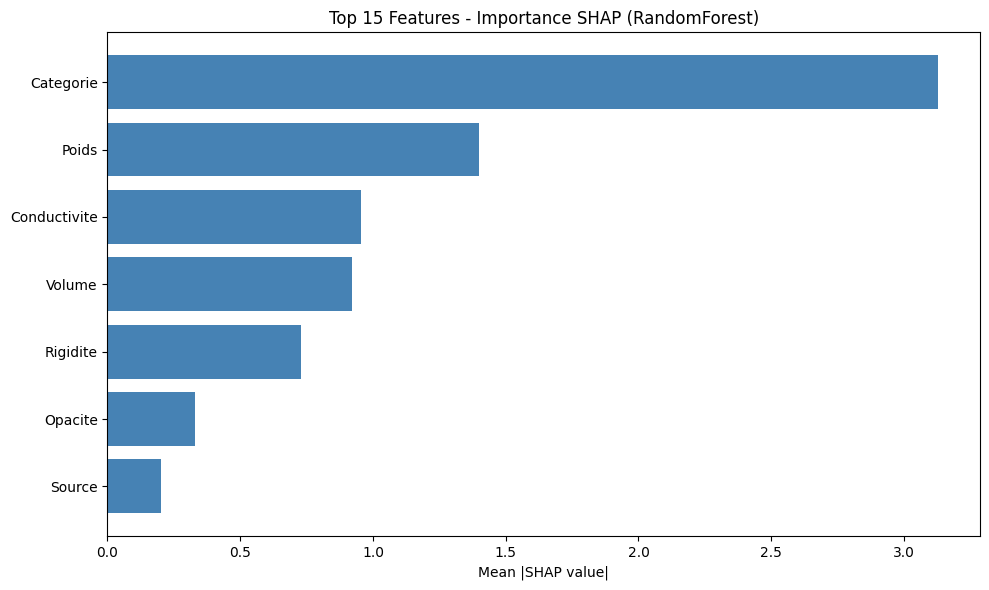

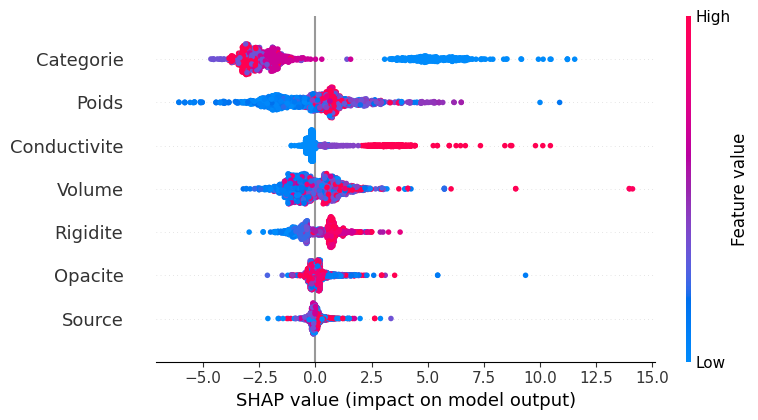

In [ ]:
# --- Graphique SHAP Bar Plot ---
plt.figure(figsize=(10, 6))
plt.barh(shap_importance['feature'][:15], shap_importance['mean_abs_shap'][:15], color='steelblue')
plt.xlabel('Mean |SHAP value|')
plt.title('Top 15 Features - Importance SHAP (RandomForest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# --- SHAP Summary Plot (beeswarm) ---
shap.summary_plot(shap_values, X_val_scaled,
                  feature_names=features,
                  max_display=15,
                  show=True)


In [ ]:
# --- Sélection des features les plus importantes ---
# On garde les features dont le SHAP moyen dépasse 1% du max
threshold = shap_importance['mean_abs_shap'].max() * 0.01
selected_features = shap_importance[shap_importance['mean_abs_shap'] >= threshold]['feature'].tolist()

print(f"Features conservées ({len(selected_features)}/{len(features)}) :")
print(selected_features)

# Réduction des datasets avec les features sélectionnées
feature_idx = [features.index(f) for f in selected_features]
X_train_shap = X_train_scaled[:, feature_idx]
X_val_shap   = X_val_scaled[:, feature_idx]
X_test_shap  = X_test_scaled[:, feature_idx]

print(f"\nNouvelle shape Train : {X_train_shap.shape}")
print(f"Nouvelle shape Test  : {X_test_shap.shape}")


Features conservées (7/7) :
['Categorie', 'Poids', 'Conductivite', 'Volume', 'Rigidite', 'Opacite', 'Source']

Nouvelle shape Train : (6806, 7)
Nouvelle shape Test  : (1459, 7)


### Tuning Optuna — Gradient Boosting & Random Forest


In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Optuna : GradientBoostingRegressor ─────────────────────────────────────
def objective_gbr(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 300),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth'       : trial.suggest_int('max_depth', 2, 6),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
    }
    model = GradientBoostingRegressor(**params, random_state=42)
    model.fit(X_train_shap, y_train)
    y_pred = model.predict(X_val_shap)
    return r2_score(y_val, y_pred)   # maximiser R²

study_gbr = optuna.create_study(direction='maximize')
study_gbr.optimize(objective_gbr, n_trials=50, show_progress_bar=False)

best_gbr_optuna = GradientBoostingRegressor(**study_gbr.best_params, random_state=42)
best_gbr_optuna.fit(X_train_shap, y_train)
y_pred_gbr_opt = best_gbr_optuna.predict(X_test_shap)

mse = mean_squared_error(y_test, y_pred_gbr_opt)
r2  = r2_score(y_test, y_pred_gbr_opt)
print("=== Optuna — GradientBoosting ===")
print("Best params:", study_gbr.best_params)
print(f"RMSE : {np.sqrt(mse):.4f} | MAE : {mean_absolute_error(y_test, y_pred_gbr_opt):.4f} | R2 : {r2:.4f}")

reg_results['GradientBoosting (Optuna+SHAP)'] = {
    'RMSE': np.sqrt(mse), 'MAE': mean_absolute_error(y_test, y_pred_gbr_opt),
    'MSE': mse, 'R2': r2, 'y_pred': y_pred_gbr_opt
}


=== Optuna — GradientBoosting ===
Best params: {'n_estimators': 236, 'learning_rate': 0.027395621054451445, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 2, 'subsample': 0.8969033380051544}
RMSE : 5.6124 | MAE : 2.5416 | R2 : 0.5707


In [ ]:
# ── Optuna : RandomForestRegressor ─────────────────────────────────────────
def objective_rf(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 50, 300),
        'max_depth'       : trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features'    : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train_shap, y_train)
    y_pred = model.predict(X_val_shap)
    return r2_score(y_val, y_pred)

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=False)

best_rf_optuna = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
best_rf_optuna.fit(X_train_shap, y_train)
y_pred_rf_opt = best_rf_optuna.predict(X_test_shap)

mse = mean_squared_error(y_test, y_pred_rf_opt)
r2  = r2_score(y_test, y_pred_rf_opt)
print("=== Optuna — RandomForest ===")
print("Best params:", study_rf.best_params)
print(f"RMSE : {np.sqrt(mse):.4f} | MAE : {mean_absolute_error(y_test, y_pred_rf_opt):.4f} | R2 : {r2:.4f}")

reg_results['RandomForest (Optuna+SHAP)'] = {
    'RMSE': np.sqrt(mse), 'MAE': mean_absolute_error(y_test, y_pred_rf_opt),
    'MSE': mse, 'R2': r2, 'y_pred': y_pred_rf_opt
}


=== Optuna — RandomForest ===
Best params: {'n_estimators': 154, 'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None}
RMSE : 5.6455 | MAE : 2.5673 | R2 : 0.5657


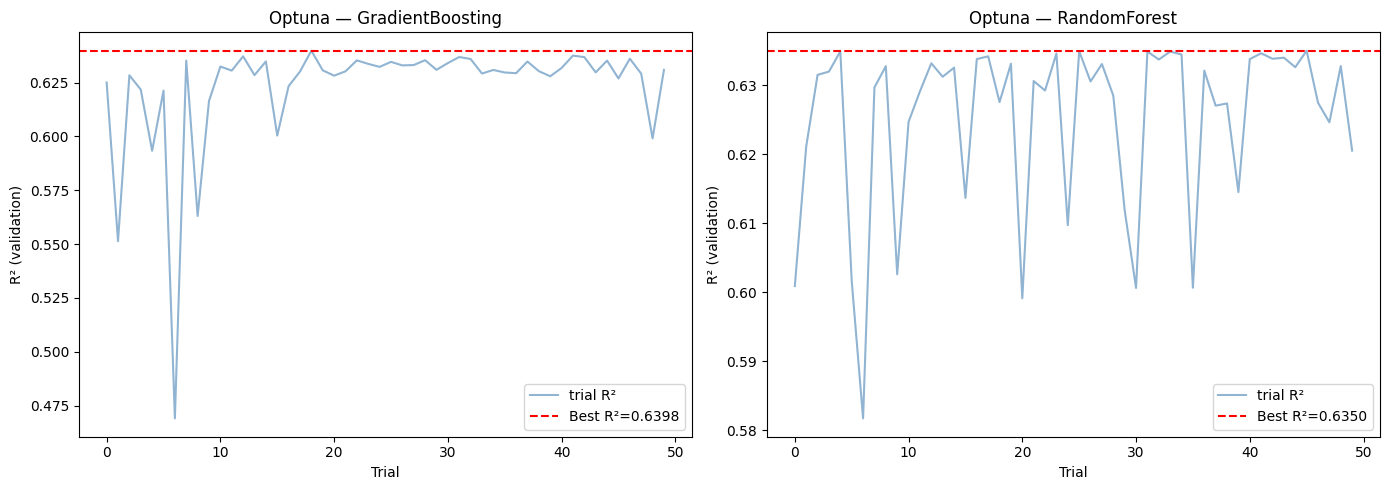

In [ ]:
# --- Visualisation : historique des trials Optuna ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, study, label in zip(axes,
                              [study_gbr, study_rf],
                              ['GradientBoosting', 'RandomForest']):
    values = [t.value for t in study.trials if t.value is not None]
    ax.plot(values, color='steelblue', alpha=0.6, label='trial R²')
    ax.axhline(max(values), color='red', linestyle='--', label=f'Best R²={max(values):.4f}')
    ax.set_title(f'Optuna — {label}')
    ax.set_xlabel('Trial')
    ax.set_ylabel('R² (validation)')
    ax.legend()

plt.tight_layout()
plt.show()


### Tableau comparatif final (tous modèles)


In [ ]:
final_df = pd.DataFrame({
    k: {m: v for m, v in r.items() if m != 'y_pred'}
    for k, r in reg_results.items()
}).T.sort_values('R2', ascending=False)

print("=== COMPARAISON FINALE ===")
display(final_df.style.highlight_max(subset=['R2'], color='lightgreen')
                      .highlight_min(subset=['RMSE', 'MAE', 'MSE'], color='lightgreen')
                      .format('{:.4f}'))

# Meilleur modèle global
best_name = final_df.index[0]
print(f"\n✅ Meilleur modèle : {best_name}")
print(final_df.loc[best_name])


=== COMPARAISON FINALE ===


,RMSE,MAE,MSE,R2
GradientBoosting (Optuna+SHAP),5.6124,2.5416,31.4989,0.5707
GradientBoosting,5.6284,2.6058,31.6786,0.5683
RandomForest (Optuna+SHAP),5.6455,2.5673,31.8717,0.5657
RandomForestRegressor,5.9175,2.4888,35.0172,0.5228
Régression polynomiale,5.9264,3.0454,35.1225,0.5213
SVR (RBF),5.9924,2.0438,35.9091,0.5106
KNN,6.0272,2.7126,36.3271,0.5049
Régression linéaire,6.2287,3.6281,38.7966,0.4713
Régression Ridge,6.2287,3.6282,38.7967,0.4713
Bayesian Ridge,6.2288,3.6297,38.7985,0.4713



✅ Meilleur modèle : GradientBoosting (Optuna+SHAP)
RMSE     5.612391
MAE      2.541619
MSE     31.498929
R2       0.570731
Name: GradientBoosting (Optuna+SHAP), dtype: float64


### Génération de la nouvelle colonne `Prix_Revente_Pred`


In [ ]:
"""
# Reconstruction du meilleur modèle sur l'ensemble complet
# On détermine si le meilleur modèle utilise les features SHAP ou toutes
uses_shap = 'SHAP' in best_name or 'Optuna' in best_name

X_full_scaled = scaler.transform(X)
if uses_shap:
    X_full_for_pred = X_full_scaled[:, feature_idx]
    best_model_obj  = best_gbr_optuna if 'GradientBoosting' in best_name else best_rf_optuna
else:
    X_full_for_pred = X_full_scaled
    best_model_obj  = reg_results   # modèle déjà fitté dans la boucle initiale
    # re-fit pour être sûr
    best_model_obj = list(models.values())[list(models.keys()).index(best_name)]
    best_model_obj.fit(X_train_scaled, y_train)

df_clean['Prix_Revente_Pred'] = best_model_obj.predict(X_full_for_pred)

print("Nouvelle colonne 'Prix_Revente_Pred' ajoutée.")
display(df_clean[['Prix_Revente', 'Prix_Revente_Pred']].head(10))

df_clean.to_csv('../data/df_clean_with_pred.csv', index=False)
print("\nDataset sauvegardé : df_clean_with_pred.csv")
"""


### GRAPHIQUE RÉELS vs PRÉDITS

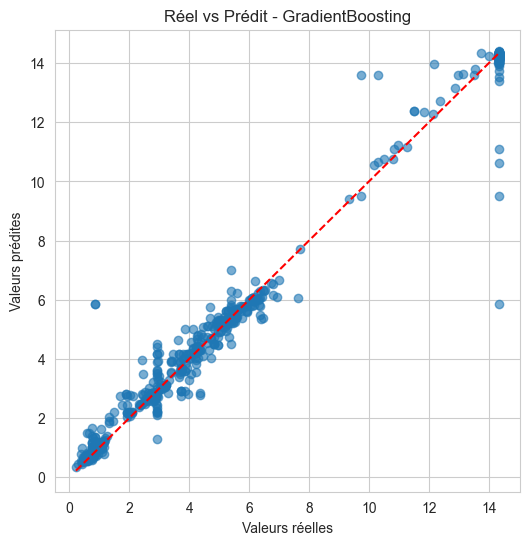

In [ ]:
best_model_name = results_df.index[0]
best_preds = reg_results[best_model_name]["y_pred"]

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title(f"Réel vs Prédit - {best_model_name}")
plt.show()